# MCMC — A Tour of the Executable Deductive Chain

**Repository**: Multiple-Collapse Cosmological Model (*Modelo Cosmológico de
Múltiples Colapsos*, MCMC). **Source of truth**: *Tratado de Fundamentos*
(v35, June 2026), DOI [10.5281/zenodo.20765373](https://doi.org/10.5281/zenodo.20765373),
as amended by the **v35.1 epistemological errata** (Aug 2026,
`docs/erratas_v35.1.md`): reclassifications E1-E13 and the C6 convention
of the four epsilons; where v35 and v35.1 differ on the status of a
claim, v35.1 prevails.

**The honesty contract this repository works under** (translated from its
working rules): every commit leaves the repository stating exactly what it
does; unfavorable outcomes are published with the same tone — and the same
front-page placement — as favorable ones; conditional results are exposed as
parameters together with their condition, never silently resolved; every
commit cites the treatise section it implements.

**Design principle of the `core/` package**: each module implements the
definitions of its treatise chapter, and its tests verify identities,
limits and numerical consequences of the implemented theorems and
ansätze — internal consistency checks of the implementation, not
physical demonstrations (v35.1, E8). Where the treatise declares a
conditional, the module exposes the parameter and says so.

This notebook walks the whole chain — axioms, Dual Plane, Basal nucleation,
Path flow, Florencia signature, Decade thresholds, Gea, the Victoria cycle
and the δ₀ circle, the mass program, cosmology and the production fits, and
Cronos v3 — **including the round-4/5 results**. It runs offline in about a
minute; the production MCMC fits are quoted from versioned results in
`results/`, not re-run here.


In [1]:
import sys
import textwrap

sys.path.insert(0, "..")   # repo root (run from notebooks/)

import matplotlib.pyplot as plt
import numpy as np

np.set_printoptions(precision=4, suppress=True)


## 1. The eight axioms (§1.2)

The only conceptual input of the model. Everything downstream is definition,
theorem, or *declared* conjecture. The deductive chain is linear: axioms 1–3
give the internal kinematics (Dual Plane, Basal potential), axiom 4 the
dynamics (Path flow), axioms 5–6 the Euclidean stretch (seals,
pre-geometric atemporality), axiom 7 the birth of time (Law of Cronos),
and axiom 8 the cyclic closure (Victoria). Axiom texts are kept in Spanish —
the working language of the treatise; names are translated in comments.


In [2]:
from mcmc_ontology.axioms import AXIOMS, REALIZATION

NAMES_EN = {1: "Dual unity", 2: "Inherited imperfection",
            3: "Primordial Tension", 4: "The Path",
            5: "Collapses and seals", 6: "Pre-geometric atemporality",
            7: "Law of Cronos", 8: "Victoria"}
for n, (name, text) in AXIOMS.items():
    print(f"A{n}. {name}  [{NAMES_EN[n]}]")
    print(textwrap.fill(text, 74, initial_indent="    ",
                        subsequent_indent="    "))
    print(textwrap.fill("realized by: " + REALIZATION[n], 74,
                        initial_indent="    -> ", subsequent_indent="       "))


A1. Unidad dual  [Dual unity]
    La realidad es una sola unidad con dos capacidades inseparables:
    condensar (Mp) y acoger (Ep). Ninguna existe sin la otra, y su
    distinción es interna, no espacial.
    -> realized by: Plano Dual (ρ,θ,χ,ς) — core.dual_plane (Defs. 2.1-2.2;
       tests: reflexión Z₂, diagonal dual); v35 §2
A2. Imperfección heredada  [Inherited imperfection]
    Todo ciclo hereda una imperfección δ₀ > 0. El caso δ₀ = 0 define el
    estado perfecto: simétrico, inerte y estéril.
    -> realized by: δ₀ input de ciclo con escalado canónico (3.2) —
       core.basal.scaled_params (test: rigidez marginal M0² ∝ δ0²); v35 §3
A3. Tensión Primordial  [Primordial Tension]
    Existe una energía liberable del ciclo, T₀ ≥ 0, con T₀ = 0 ⟺ δ₀ = 0.
    -> realized by: T₀ = c̄·δ₀³ — core.basal.T0_numeric (test: exponente 3
       medido; T0=0 ⟺ δ0=0); v35 Prop. 3.4
A4. El Camino  [The Path]
    La evolución fundamental es descarga de tensión por la vía de mínima
    resistencia;

## 2. The Basal potential — the landscape of imperfection (Ch. 3)

$$V_0(\rho,\chi;\delta_0)=\tfrac12 M_0^2\rho^2-\tfrac B4\rho^4+
\tfrac{C_0}{6}\rho^6-\eta\chi,\qquad
M_0^2=\bar m^2\delta_0^2,\; B=\bar b\,\delta_0,\; \eta=\bar e\,\delta_0^3$$

The scaling (eq. 3.2) makes the whole landscape a function of the single
cycle input $\delta_0$ and O(1) shape constants. Two facts with tests:
the Primordial Tension obeys $T_0=\bar c\,\delta_0^3$ (Prop. 3.4 — the
exponent is *measured* below, not assumed), and the $\delta_0=0$ control is
flat to sixth order: the perfect state is inert and sterile (Axioms 2–3).


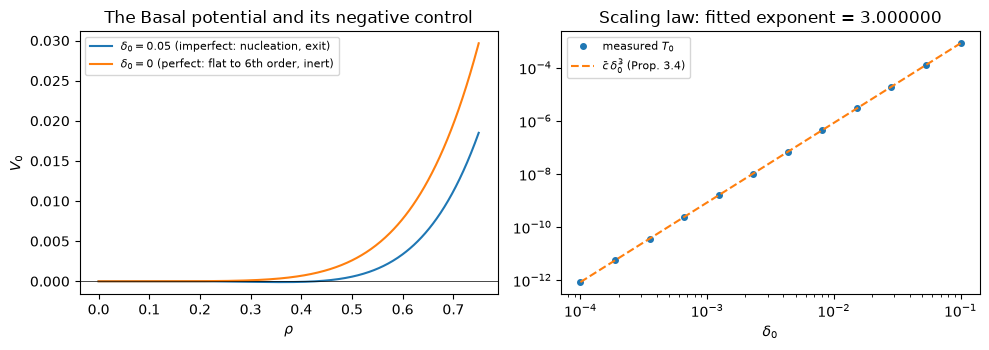

kappa_+ = 2.618034  (fiducial shapes: (3+sqrt(5))/2)
c_bar   = 0.840847


In [3]:
from core.basal import V0, T0_analytic, T0_numeric, c_bar, kappa_plus

rho = np.linspace(0.0, 0.75, 400)
fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
for d0, lab in ((0.05, r"$\delta_0=0.05$ (imperfect: nucleation, exit)"),
                (0.0, r"$\delta_0=0$ (perfect: flat to 6th order, inert)")):
    ax[0].plot(rho, V0(rho, 0.0, d0), label=lab)
ax[0].axhline(0, color="k", lw=0.5); ax[0].legend(fontsize=8)
ax[0].set_xlabel(r"$\rho$"); ax[0].set_ylabel(r"$V_0$")
ax[0].set_title("The Basal potential and its negative control")

deltas = np.logspace(-4, -1, 12)
T0s = np.array([T0_numeric(d) for d in deltas])
slope = np.polyfit(np.log(deltas), np.log(T0s), 1)[0]
ax[1].loglog(deltas, T0s, "o", ms=4, label="measured $T_0$")
ax[1].loglog(deltas, T0_analytic(1.0) * deltas**3, "--",
             label=r"$\bar c\,\delta_0^3$ (Prop. 3.4)")
ax[1].legend(fontsize=8); ax[1].set_xlabel(r"$\delta_0$")
ax[1].set_title(f"Scaling law: fitted exponent = {slope:.6f}")
plt.tight_layout(); plt.show()

print(f"kappa_+ = {kappa_plus():.6f}  (fiducial shapes: (3+sqrt(5))/2)")
print(f"c_bar   = {c_bar():.6f}")


## 3. The arrow of time as a theorem (Ch. 4)

The Path flow is gradient descent of $V_0$ with positive-definite rigidity
$G$. Monotonicity (Thm. 4.5) and Exclusion (Lemma 4.7) make "no return"
a *checked* property, not a postulate. One subtlety the tests document:
the origin is a **metastable false vacuum** — the exit from $S_0$ is Coleman
nucleation (Prop. 3.5), not classical rolling. Starting just past the
barrier, the flow falls toward the **mass pole** ($\theta\to 0$) and lands
on the vacuum ring $\rho_+=\sqrt{\kappa_+\delta_0}$.


exits to mass pole: True
final point: [0.3647 0.    ]  (theta -> 0: the mass pole)
|final| = 0.3647  vs  rho_+ = 0.3618
V strictly non-increasing: True


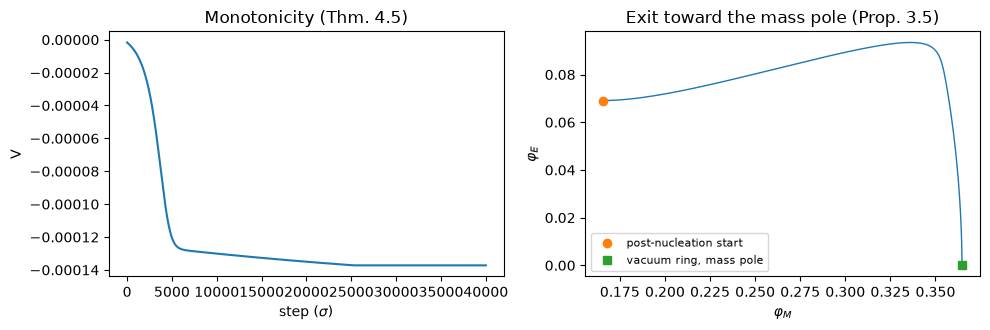

In [4]:
from core.basal import kappa_plus
from core.path_flow import exits_to_mass_pole, flow

delta0 = 0.05
rho_barrier = float(np.sqrt(0.382 * delta0))          # x_- = kappa_- d0
phi0 = np.array([1.2 * rho_barrier, 0.5 * rho_barrier])  # post-nucleation
res = flow(phi0, delta0=delta0, d_sigma=0.05, n_steps=40000)

rho_final = float(np.linalg.norm(res["final"]))
rho_plus = float(np.sqrt(kappa_plus() * delta0))
print(f"exits to mass pole: {exits_to_mass_pole(res)}")
print(f"final point: {res['final']}  (theta -> 0: the mass pole)")
print(f"|final| = {rho_final:.4f}  vs  rho_+ = {rho_plus:.4f}")
print(f"V strictly non-increasing: {bool(np.all(np.diff(res['V']) <= 1e-12))}")

fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
ax[0].plot(res["V"]); ax[0].set_xlabel(r"step ($\sigma$)")
ax[0].set_ylabel("V"); ax[0].set_title("Monotonicity (Thm. 4.5)")
ax[1].plot(res["trajectory"][:, 0], res["trajectory"][:, 1], lw=1)
ax[1].plot(*phi0, "o", label="post-nucleation start")
ax[1].plot(*res["final"], "s", label="vacuum ring, mass pole")
ax[1].set_xlabel(r"$\varphi_M$"); ax[1].set_ylabel(r"$\varphi_E$")
ax[1].legend(fontsize=8); ax[1].set_title("Exit toward the mass pole (Prop. 3.5)")
plt.tight_layout(); plt.show()


## 4. The Florencia Rotation — the signature of spacetime (Chs. 5–6)

The Chain of Algebras is Euclidean, $C(d{+}1,0)$. At the Florencia
threshold **one single generator** rotates, $\gamma^0=i\gamma_S$ (eq. 6.2),
and the signature becomes exactly $(-,+,+,+)$. The negative control —
rotating *two* generators — produces two time directions: no light cone.


In [5]:
from core.florencia import chain_generators, florencia_rotation, signature

gens = chain_generators(3)
print("before (C(4,0)):        ", signature(gens))
print("one rotation (eq. 6.2): ", signature(florencia_rotation(gens)))
print("two rotations (control):", signature(florencia_rotation(gens, n_rotations=2)))


before (C(4,0)):         [1, 1, 1, 1]
one rotation (eq. 6.2):  [-1, 1, 1, 1]
two rotations (control): [-1, 1, 1, -1]


## 5. The Law of the Decade (Ch. 8)

Collapse thresholds $S_k=\lambda^{k-2}-\Delta S$ with the anticipation
quantum, plus the confirmation quantum at Florencia (Prop. 8.1). The
Discriminant $D=B^2-4C_0M_0^2$ drives the KLS-type radial flow; the walking
period diverges when approaching the spinodal ($D\to 0^-$), and
$\lambda=e^{\pi/s_0}$ links the Decade ratio to Victoria's exponent
($\lambda=10$ is **calibrated** — its derivation is open front #2).


In [6]:
from core.decade import s0_from_lambda, walk_period
from mcmc_ontology.constants import S0_VICTORIA, S_SEALS, decade_thresholds

print("Decade thresholds (Prop. 8.1):", decade_thresholds())
print("Seals in constants.S_SEALS:   ", [S_SEALS[k] for k in ("C1","C2","C3","C4")])
print(f"s0 = pi/ln(10) = {s0_from_lambda(10.0):.6f}  (= S0_VICTORIA: "
      f"{abs(s0_from_lambda(10.0) - S0_VICTORIA) < 1e-12})")
t_deep = walk_period(2.0, M0_sq=2.0, C0=1.0)
t_near = walk_period(2.0, M0_sq=1.01, C0=1.0)
print(f"walking period: deep D<0 -> {t_deep:.3f};  near spinodal -> "
      f"{t_near:.3f}  (diverges, eq. 8.4)")


Decade thresholds (Prop. 8.1): [0.009000000000000001, 0.099, 0.999, 1.001]
Seals in constants.S_SEALS:    [0.009, 0.099, 0.999, 1.001]
s0 = pi/ln(10) = 1.364376  (= S0_VICTORIA: True)
walking period: deep D<0 -> 1.571;  near spinodal -> 15.708  (diverges, eq. 8.4)


## 6. Gea: Newton's Seal and the Residues contrast (Ch. 9)

At the fixed point $(\lambda_K,\xi)=(1,1)$, $G_{\rm cosmo}=G_N$
**exactly** — general relativity is recovered, with a test. Away from it,
the *declared conjecture* 9.6 (eq. 9.5) predicts
$G_{\rm cosmo}/G_N-1\simeq-\tfrac32\varepsilon_K\approx-1.8\%$. This is
the model's one observational **consistency check passed** (round 4,
option D): inside the BBN bound, ~0.3σ from center. At that significance
there is no detection and no sign preference (v35.1, E13) — the check
could have excluded the predicted value and did not. Output below is in
Spanish (the repo's working language).


In [7]:
from core.gea import STATUS_RESIDUOS, newton_seal_ratio, residues_prediction
from cosmology.residues_test import report

print(f"Newton seal at (1,1): ratio = {newton_seal_ratio(1.0, 1.0)} (exact)")
print(f"Residues prediction (eps_K = 0.012): {residues_prediction(0.012):+.4f}")
print("status:", STATUS_RESIDUOS)
print()
print(report())


Newton seal at (1,1): ratio = 1.0 (exact)
Residues prediction (eps_K = 0.012): -0.0180
status: conjetura (9.6; frente abierto nº 6)

G_cosmo/G_N predicho = 0.982 (-1.8%); cota BBN 0.99 +0.06/−0.05 (2σ): dentro=True, tensión=0.32σ — consistencia superada, sin significancia de signo (coincidencia descriptiva=True; v35.1, E13) [Alvey, Sabti, Escudero & Fairbairn (2020), Eur. Phys. J. C 80, 148; arXiv:1910.10730]


## 7. The Victoria cycle and the circle of δ₀ (Ch. 10; rounds 4–5)

The return map (Thm. 10.6) has an activation floor (below it: the
**Silence of Victoria**, a real outcome, not discarded) and a Ceiling
$W_{\max}$ (Lemma 10.3). Fertility, $\nu>0\iff\gamma_R\bar e>\bar m^2$
(eq. H.7), is a **conditional**: the sign waits for the restart
microdynamics (open front #4). Monte Carlo over O(1) landscapes: ~72% of
the sampled region is fertile.

**Round 5, the circle of δ₀** — the C¹ splice (below, §8) *measures*
$\delta_H\approx0.0581$; does the Victoria attractor converge to it? The
computation establishes: in the whole fertile region the attractor **is the
Ceiling**, $\delta_\infty=(W_{\max}/\bar c)^{1/3}$, independent of
$\gamma_R$ and of the initial value. So the circle closes **iff**
$W_{\max}=\bar c\,\delta_H^3\approx1.65\times10^{-4}$: a consistency
equation linking Thm. 10.6 to eq. H.8. The treatise does not quantify
$W_{\max}$, so the computation neither closes nor breaks the circle — it
**transfers the question** to $W_{\max}$. Bonus finding: over the entire
O(1) landscape, $\delta_H\gtrsim0.033$ — *no* O(1) shape closes the
splice at 0.012, independently reinforcing the canonical rule that
separates $\delta_0$ from $\varepsilon_\Lambda$ (see §8).


In [8]:
from core.delta0_circle import (
    W_max_required,
    closure_test,
    consistency_factors,
    delta0_H,
    landscape_scan,
)
from core.victoria import iterate_cycles

# spiral vs silence (Thm. 10.6):
up = iterate_cycles(1e-3, gamma_R=2.0, n_cycles=30, delta_min=1e-4, delta_sat=0.1)
down = iterate_cycles(1e-3, gamma_R=0.5, n_cycles=30, delta_min=1e-4, delta_sat=0.1)
print(f"fertile (A=2):   {len(up)-1} cycles -> {up[-1]} (the ceiling)")
print(f"infertile (A=.5): ends at {down[-1]} (the Silence of Victoria)")

d_H = delta0_H()
W_close = W_max_required(d_H)
print(f"\ndelta_H (splice) = {d_H:.5f};  closing W_max = c*d_H^3 = {W_close:.4e}")
ct = closure_test(W_close, gamma_R=1.5, delta_min=1e-4, delta_init=0.012)
print(f"with that ceiling, attractor from 0.012: {ct['attractor']:.5f} "
      f"in {ct['cycles_to_settle']} cycles -> closes: {ct['closes']}")
bad = closure_test(0.5 * W_close, gamma_R=1.5, delta_min=1e-4, delta_init=0.012)
print(f"negative control (W_max/2): attractor {bad['attractor']:.5f} "
      f"-> closes: {bad['closes']}  (0.058 is NOT intrinsic to the map)")

f = consistency_factors()
print(f"\nif delta_0 = delta_H: T0 x{f['T0_ratio']:.1f} (Prop. 3.4), "
      f"m_theta^2 x{f['m_theta_sq_ratio']:.1f} (eq. 10.1)")

scan = landscape_scan(n=4000, seed=5)
p = scan["delta_H_percentiles"]
print(f"\ndelta_H over fertile O(1) landscapes: median {p[50]:.4f}, "
      f"5-95% [{p[5]:.4f}, {p[95]:.4f}], min {scan['delta_H'].min():.4f}")
print("-> no O(1) shape reaches 0.012: the splice cannot close there.")


fertile (A=2):   30 cycles -> 0.1 (the ceiling)
infertile (A=.5): ends at 0.0 (the Silence of Victoria)

delta_H (splice) = 0.05814;  closing W_max = c*d_H^3 = 1.6523e-04
with that ceiling, attractor from 0.012: 0.05814 in 4 cycles -> closes: True
negative control (W_max/2): attractor 0.04614 -> closes: False  (0.058 is NOT intrinsic to the map)

if delta_0 = delta_H: T0 x113.7 (Prop. 3.4), m_theta^2 x51.7 (eq. 10.1)

delta_H over fertile O(1) landscapes: median 0.0543, 5-95% [0.0370, 0.1136], min 0.0332
-> no O(1) shape reaches 0.012: the splice cannot close there.


## 8. The mass program and the C¹ splice (Ch. 12, App. H.2.4; round 4)

Status per treatise 12.5 as amended: structural — the tensional seesaw
and the Path Functional form; $N_{\rm gen}=3$ is a structural
**identification pending derivation** (v35.1, E4: Prop. 12.4 is stated
without proof; the derivation is a sub-front of front #7); pending or
potentially circular — the WKB weights $c_{in}$ and an independent
derivation of $\beta_3$ (Obs. 12.2). The published $m_H\simeq125.3$ GeV is the SM identity with
calibrated $\beta_3$ — **not claimed as a prediction** while front #7 is open.

**Round 4 executed front #7 (option A).** The C¹ splice (eq. H.8) computes
the sealed curvature $\lambda_{\rm Ad}=\delta_0\sqrt{\bar b^2-4C_0\bar m^2}$
from `core.basal` — the measured Higgs mass enters nowhere (verified by a
test that perturbs it). Outcome, published as-is: closure requires
$\delta_0^*\approx0.0581$, **not** the 0.012 of $\varepsilon_\Lambda$
that v32 identified with $\delta_0$. Hence the round-5 **canonical rule**:
*never identify $\delta_0$ with $\varepsilon_\Lambda$* — v35 keeps four
separate symbols ($\varepsilon$ collapse residue, $\varepsilon_\Lambda$
transition amplitude $0.012\pm0.003$, $\varepsilon_K$ gravitational
residue, $\delta_0$ cycle input with **no assigned numeric value**).
The ab-initio WKB ladder (B8) shows one action scale $\kappa$ covers the
13 orders of magnitude $m_t/m_\nu$ with monotone depths.


In [9]:
import textwrap as _tw

import mass_program.B7_empalme as B7
from mass_program.B8_wkb_ab_initio import MASS_LADDER_GEV, kappa_minimum, ladder

print(_tw.fill(B7.audit_report(), 78))
print()
lad = ladder(0.05)["E"]
print(f"WKB ladder (delta0 = 0.05, kappa_min = {kappa_minimum(0.05):.3g}):")
for k in sorted(lad, key=lad.get, reverse=True):
    print(f"  {k:>7s}: E = {lad[k]:.4e}   (m = {MASS_LADDER_GEV[k]:.3g} GeV)")
print("heavier = shallower; the neutrino sits deepest (seesaw link, Prop. 12.5)")


Empalme C¹ (H.8), sin m_H como entrada: λ_Ad(δ0=0.012) = 0.0268 → m_H = 57.0
GeV (≠ 125.3). El cierre λ_Ad = 0.130 exige δ_H = 0.0581 con las formas
fiduciales O(1). CONCLUSIÓN: relación no circular implementada; el valor
numérico de β3 con (M0²,B,C0) sellados sigue CONDICIONAL (Estado de H.2.4) —
el frente queda acotado: o δ0 ≈ 0.058 en el sello, o formas no fiduciales. La
auditoría de la Obs. 12.2 se conserva.



WKB ladder (delta0 = 0.05, kappa_min = 7.4e+04):
        t: E = 1.0220e-05   (m = 173 GeV)
        b: E = 9.0238e-06   (m = 4.2 GeV)
      tau: E = 8.7496e-06   (m = 1.77 GeV)
        c: E = 8.6471e-06   (m = 1.28 GeV)
       mu: E = 7.8660e-06   (m = 0.106 GeV)
        s: E = 7.8353e-06   (m = 0.096 GeV)
        d: E = 6.9139e-06   (m = 0.0048 GeV)
        u: E = 6.6906e-06   (m = 0.0023 GeV)
        e: E = 6.2431e-06   (m = 0.00052 GeV)
   nu_tau: E = 1.2735e-06   (m = 6e-12 GeV)
heavier = shallower; the neutrino sits deepest (seesaw link, Prop. 12.5)


## 9. Cosmology and the production fits (App. A; rounds 2 and 4)

$\Lambda_{\rm rel}(z)$ turns on at the transition ($z_t=8.9\pm0.4$, width
$\Delta z=1.5$, tanh — App. A.3), **normalized today**:
$\Omega_{\Lambda,\rm rel}(z)=\Omega_{\Lambda 0}\,F(z)/F(0)$, with flat
closure imposed per call ($\Omega_{\rm DE,0}=1-\Omega_m-\Omega_r$), so
$H(0)=H_0$ holds *exactly* for every admissible parameter — an invariant
protected by `tests/test_physical_invariants.py` (Aug-2026 normalization
fix; the original form biased $H(0)$ by $\approx+0.4\%$ at the fiducial
point, and only in the MCMC arm). **Recovery limit (Prop. A.1)**: at
$\varepsilon=0$ the model *is* ΛCDM exactly — an identity, checked below.

**The production fits — the honest headline of this repository.** The
original runs (Jul/Aug 2026) predate the normalization fix and are kept as
`legacy_pre_normalization`; the table below cites the **2026-08-10 re-run
on the corrected background** (same seeds, data and settings), which
confirms the differential verdict:

| Fit (re-run 2026-08-10) | Data (n) | ΔAIC | ΔBIC (MCMC − ΛCDM) |
|---|---|---|---|
| v1 (legacy: +4.03/+14.53) | CC + BAO + SNe (1408) | **+4.00** | **+14.50** |
| v2 "reconciliation" (legacy: +4.01/+14.53) | + compressed CMB + fσ8 (1422) | **+4.08** | **+14.60** |

Positive values favor **ΛCDM**. Both runs converged (v2: 24×8000,
$\tau$ criterion satisfied); $\varepsilon=0.018^{+0.043}_{-0.041}$ —
compatible with 0, now from unbiased posteriors. The corpus-referenced
advantage (ΔBIC ≈ −6, H₀ ~ 69–70)
**did not reappear** when adding the two probes it came from; whatever
advantage the corpus reported lives in likelihoods this repo has not yet
implemented (full $C_\ell$, lensing) or in methodology. Published on the
README front page as-is — that is the contract. Chains and per-block χ²
in `results/2026-08-10_production_fit/` and
`results/2026-08-10_production_fit_v2/` (legacy runs preserved in the
Jul-31 / Aug-01 directories).


Prop. A.1 at eps=0: max |H_MCMC - H_LCDM| = 0.00e+00 km/s/Mpc (exact identity)
Invariant H(0)=H0 over the (Omega_m, eps) grid: max deviation = 0.00e+00 km/s/Mpc


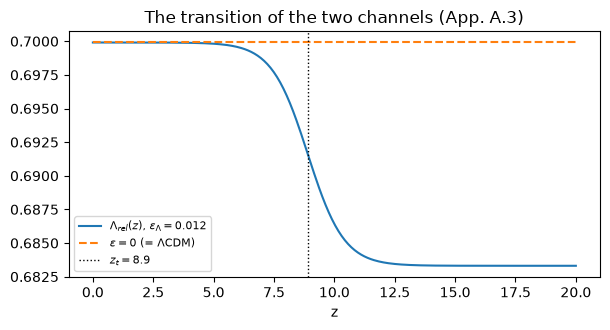

In [10]:
from cosmology.background import OMEGA_L0, H_of_z, Lambda_rel
from mcmc_ontology import constants as Cst

z = np.linspace(0.0, 1100.0, 500)
lcdm = 69.8 * np.sqrt(0.300*(1+z)**3 + 9.2e-5*(1+z)**4 + OMEGA_L0)
mcmc_eps0 = H_of_z(z, eps=0.0)
print(f"Prop. A.1 at eps=0: max |H_MCMC - H_LCDM| = "
      f"{float(np.max(np.abs(mcmc_eps0 - lcdm))):.2e} km/s/Mpc (exact identity)")

# Physical invariant (level-3 CI): H(0) = H0 for EVERY admissible theta,
# not only at the fiducial point (the pre-fix code violated exactly this).
devs = [abs(float(H_of_z(0.0, H0=67.4, Omega_m=om, eps=e)) - 67.4)
        for om in (0.20, 0.30, 0.40) for e in (-0.04, 0.0, 0.05)]
print(f"Invariant H(0)=H0 over the (Omega_m, eps) grid: "
      f"max deviation = {max(devs):.2e} km/s/Mpc")

zz = np.linspace(0, 20, 300)
plt.figure(figsize=(6.2, 3.4))
plt.plot(zz, Lambda_rel(zz, eps=Cst.EPSILON_LAMBDA), label=r"$\Lambda_{rel}(z)$, $\varepsilon_\Lambda=0.012$")
plt.plot(zz, Lambda_rel(zz, eps=0.0), "--", label=r"$\varepsilon=0$ (= $\Lambda$CDM)")
plt.axvline(Cst.Z_TRANS, color="k", ls=":", lw=1, label=r"$z_t = 8.9$")
plt.xlabel("z"); plt.legend(fontsize=8)
plt.title("The transition of the two channels (App. A.3)")
plt.tight_layout(); plt.show()


## 10. Cronos v3 and the gate (Ch. 11, App. B/H.2.5; round 5 half-step)

Weak Law of Cronos: $N=1+\Phi_N/c^2-\varepsilon_c$,
$\varepsilon_c=\alpha_0^{-1}(\rho/\rho_c)^{3/2}$, with the hard falsable
bound $\alpha_0^{-1}\lesssim10^{-6}$ (eq. 11.5). The gate friction
$\Gamma=\tfrac32(\dot\rho/\rho)\varepsilon_c\Theta(\dot\rho)$ is
active only while the region collapses — H.2.5: *"virialized halos must
show no residual Cronos friction"*. The mini-run below (isolated cold
clump, ~2 s) shows the signature; the round-5 half-step
(`results/2026-08-02_profile_shape/`) adds: median tail Γ = 0 exactly, the
ungated form (11.3b) persists (negative control), the emergent profile at
this resolution is cuspy in *both* A/B runs (core verdict needs production),
and a **validity finding**: $\rho_c$ must be the collapse threshold
(~200× mean) — with $\rho_c\sim$ mean, $\varepsilon_c$ reaches O(1),
leaving the weak regime and condensing the halo into a point (a verified
artifact, not physics). The treatise's absolute values
($\approx4\times10^{-4}\to\approx7\times10^{-9}$) belong to its
production simulation.


gated:   Gamma_collapse = 1.10e-05 -> tail max 1.51e-07, median 0.0e+00 (Gamma=0 in 83% of tail steps)
ungated (11.3b, old scheme): drops only 0.20 orders -> persists (negative control)


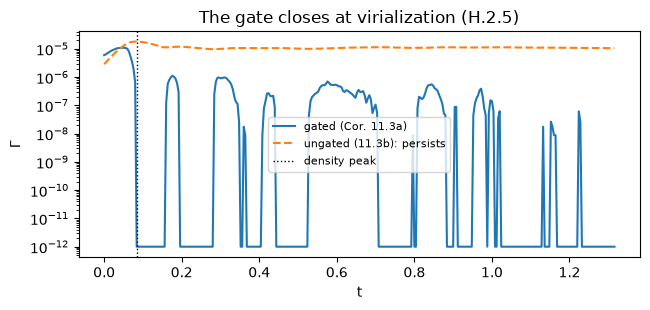

In [11]:
from cronos.profile_fit import (
    friction_drop,
    gate_histories,
    spherical_clump_ic,
    track_region_density,
)
from cronos.simulation import CronosPM

n_p = 1024
pos, vel, mass = spherical_clump_ic(20260802, n_p, 10.0)
rho_c = 200.0 * n_p / 1000.0        # collapse threshold: 200 x mean
sim = CronosPM(pos, vel, mass, grid_n=16, box=10.0, alpha0_inv=1e-6, rho_c=rho_c)
rho = track_region_density(sim, 350, 0.004, 1.0)
gh = gate_histories(rho, 0.004, 1e-6, rho_c)
d = friction_drop(gh["gated"], gh["i_peak"], tail_frac=0.25)
p = friction_drop(gh["ungated"], gh["i_peak"], tail_frac=0.25)

print(f"gated:   Gamma_collapse = {d['Gamma_collapse']:.2e} -> tail max "
      f"{d['Gamma_virial']:.2e}, median {d['Gamma_virial_median']:.1e} "
      f"(Gamma=0 in {d['tail_zero_frac']:.0%} of tail steps)")
print(f"ungated (11.3b, old scheme): drops only {p['orders_drop']:.2f} "
      "orders -> persists (negative control)")

t = np.arange(len(gh["gated"])) * 0.004
plt.figure(figsize=(6.6, 3.2))
plt.semilogy(t, np.maximum(gh["gated"], 1e-12), label="gated (Cor. 11.3a)")
plt.semilogy(t, gh["ungated"], "--", label="ungated (11.3b): persists")
plt.axvline(gh["i_peak"] * 0.004, color="k", ls=":", lw=1, label="density peak")
plt.xlabel("t"); plt.ylabel(r"$\Gamma$"); plt.legend(fontsize=8)
plt.title("The gate closes at virialization (H.2.5)")
plt.tight_layout(); plt.show()


## 11. Balance: proven, conditional, refutable

The Appendix-H mirror suite (`validation/appendix_h.py`) runs the sign
checks of §13.5, the three recovery limits, and their **negative controls**
(the case that must fail, and does). Output in Spanish. The open fronts, in
English: **#1** non-stationary reflection positivity; **#2** is λ=10 physics
or gauge convention; **#4** restart microdynamics (sign of ν — and now also
$W_{\max}$, where the δ₀ circle transferred its question); **#5** Cronos v3
in production (Gadget-4-Cronos: 2.3 kpc core, SPARC, subhalos); **#6**
$G_{\rm cosmo}/G_N$ measurement; **#7** WKB weights $c_{in}$ and the
independent derivation of β3.

What the production fits add to the balance: on background + compressed CMB
+ growth data, the ε-transition is **not favored** over ΛCDM (ΔBIC = +14.5/+14.6,
confirmed by the 2026-08-10 re-run on the corrected background) and ε is
compatible with 0 — while the Residues consistency check (§6) is
passed without sign significance and stays alive (refutable). Both
statements are published with equal weight.


In [12]:
from validation.appendix_h import run_all

summary = run_all(verbose=True)


--- Suite espejo del apéndice H (verificaciones + controles negativos) ---
  [OK  ] T0 ≥ 0 con igualdad sii δ0 = 0  (Prop. 3.4 / Def. 3.3)
  [CTRL] sin casi-cancelación (3.3) no hay vacío más profundo  (ec. (3.3))
  [OK  ] dV/dσ ≤ 0 y producción entrópica ≥ 0  (Teo. 4.5)
  [CTRL] el flujo invertido viola la monotonía (detectado)  (Teo. 4.5)
  [OK  ] símbolo euclidiano definido positivo  (Lema 5.2)
  [CTRL] el símbolo lorentziano NO es definido (detectado)  (Lema 5.2)
  [OK  ] (γ⁰)² = −𝟙 con un solo generador girado → firma (−,+,+,+)  (ec. (6.2) / §13.5)
  [CTRL] girar dos generadores no da un cono de luz (detectado)  (§13.5)
  [OK  ] ⟨ϑ(F̄)·F⟩ ≥ 0 en el retículo de juguete  (Teo. 7.1)
  [CTRL] el acoplo temporal invertido rompe la RP (detectado)  (Teo. 7.1)
  [OK  ] N < 1 en regiones densas (signo corregido)  (Def. 11.1 / Obs. 11.4)
  [CTRL] el signo antiguo (+ε_c) da N > 1 en denso (detectado)  (Obs. 11.4)
  [OK  ] Γ > 0 solo durante el colapso (Θ(ρ̇))  (Cor. 11.3a)
  [CTRL] la fricci